In [ ]:
# ===============================
# Jupyter Notebook: K线 + 交易点 + 滑动条 + 美化
# ===============================

import pandas as pd
import plotly.graph_objects as go
from vnpy.trader.constant import Direction, Offset
from run_backtest import run_backtest  # 你的回测脚本

# -------------------------------
# 1️⃣ 运行回测
# -------------------------------
engine = run_backtest()       # 确保 run_backtest 返回 engine
strategy = engine.strategy

# -------------------------------
# 2️⃣ 获取长周期 BarData
# -------------------------------
bars_list = getattr(strategy, "bg_long_bars", [])
if not bars_list:
    raise RuntimeError("策略没有保存 BarData，请确保在 on_long_bar 中 append BarData")

# -------------------------------
# 3️⃣ 最近 N 根
N = 200
bars_list = bars_list[-N:]

# -------------------------------
# 4️⃣ 转 DataFrame
# -------------------------------
df = pd.DataFrame([{
    "datetime": b.datetime,
    "open": b.open_price,
    "high": b.high_price,
    "low": b.low_price,
    "close": b.close_price,
    "volume": b.volume
} for b in bars_list])

# -------------------------------
# 5️⃣ 添加交易点列
# -------------------------------
df["long_entry"] = False
df["long_exit"] = False
df["short_entry"] = False
df["short_exit"] = False

for t in engine.trades.values():
    t_dt = t.datetime
    mask = df["datetime"] <= t_dt
    if mask.any():
        idx = df[mask].index[-1]
        if t.direction == Direction.LONG and t.offset == Offset.OPEN:
            df.at[idx, "long_entry"] = True
        elif t.direction == Direction.LONG and t.offset == Offset.CLOSE:
            df.at[idx, "long_exit"] = True
        elif t.direction == Direction.SHORT and t.offset == Offset.OPEN:
            df.at[idx, "short_entry"] = True
        elif t.direction == Direction.SHORT and t.offset == Offset.CLOSE:
            df.at[idx, "short_exit"] = True

# -------------------------------
# 6️⃣ 绘制 Plotly K 线 + 交易点 + 滑动条
# -------------------------------
fig = go.Figure()

# K线
fig.add_trace(go.Candlestick(
    x=df["datetime"],
    open=df["open"],
    high=df["high"],
    low=df["low"],
    close=df["close"],
    name="Kline",
    increasing_line_color='lime',
    decreasing_line_color='red',
    whiskerwidth=0.3,
    opacity=0.9
))

# 交易点
markers = [
    ("long_entry", "triangle-up", "green"),
    ("long_exit", "triangle-down", "red"),
    ("short_entry", "triangle-down", "blue"),
    ("short_exit", "triangle-up", "orange")
]

for col, symbol, color in markers:
    fig.add_trace(go.Scatter(
        x=df.loc[df[col], "datetime"],
        y=df.loc[df[col], "close"],
        mode="markers",
        marker=dict(symbol=symbol, color=color, size=14, line=dict(color="white", width=1)),
        name=col.replace("_", " ").title()
    ))

# -------------------------------
# 7️⃣ 布局美化
# -------------------------------
fig.update_layout(
    title="Backtest Kline with Trades",
    xaxis_title="Datetime",
    yaxis_title="Price",
    xaxis_rangeslider_visible=True,
    xaxis_rangeslider_thickness=0.12,
    template="plotly_dark",
    font=dict(family="Courier New", size=12, color="white"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# -------------------------------
# 8️⃣ 显示
# -------------------------------
fig.show()


=== vn.py 回测脚本 ===
当前工作目录: d:\finance\data\vnpy_ctabacktester\samir
Python路径: c:\veighna_studio\python.exe
成功导入策略: LlmStrategyExact
正在加载数据...
2025-12-11 14:31:10.847615	开始加载历史数据
2025-12-11 14:31:10.847765	加载进度：# [0%]
2025-12-11 14:31:10.848280	加载进度：# [10%]
2025-12-11 14:31:10.848546	加载进度：## [20%]
2025-12-11 14:31:10.849243	加载进度：### [30%]
2025-12-11 14:31:10.850006	加载进度：#### [40%]
2025-12-11 14:31:10.850750	加载进度：##### [50%]
2025-12-11 14:31:10.851480	加载进度：###### [60%]
2025-12-11 14:31:10.852280	加载进度：####### [70%]
2025-12-11 14:31:10.853208	加载进度：######## [80%]
2025-12-11 14:31:10.854153	加载进度：######### [90%]
2025-12-11 14:31:10.854705	加载进度：########## [99%]
2025-12-11 14:31:10.854749	历史数据加载完成，数据量：349967
数据加载完成
开始回测...
2025-12-11 14:31:10.854801	策略初始化完成
2025-12-11 14:31:10.854813	开始回放历史数据
2025-12-11 14:31:10.959585	回放进度：= [0%]
2025-12-11 14:31:11.070984	回放进度：== [10%]
2025-12-11 14:31:11.177118	回放进度：=== [20%]
2025-12-11 14:31:11.280669	回放进度：==== [30%]
2025-12-11 14:31:11.374026	回放进度：===== [4

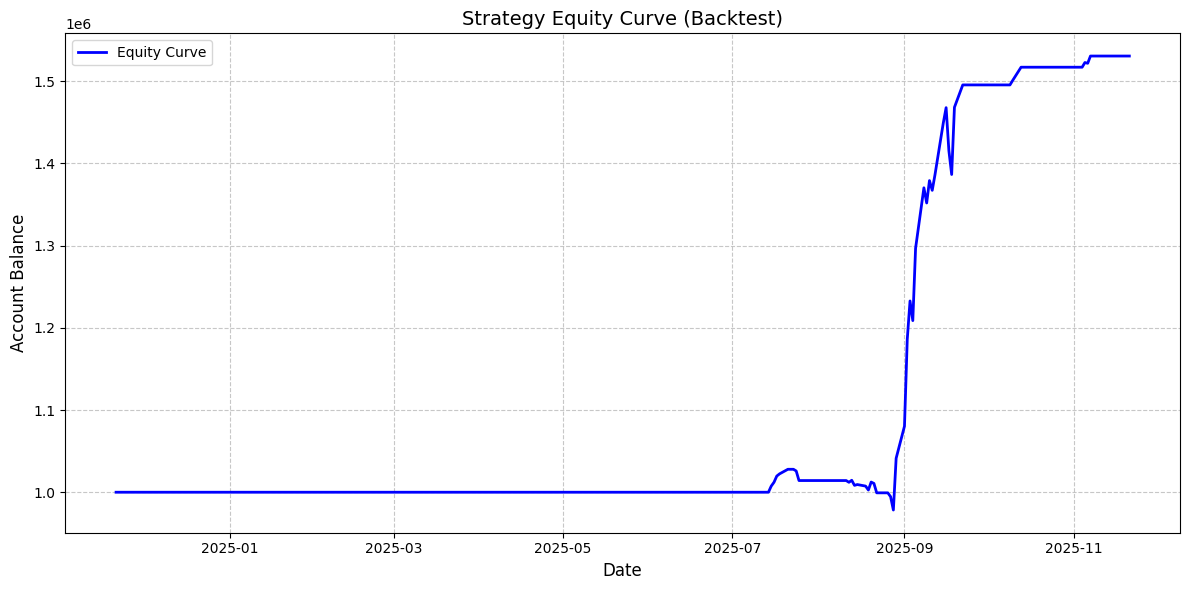

2025-12-11 14:31:20.585387	开始计算策略统计指标
2025-12-11 14:31:20.588299	------------------------------
2025-12-11 14:31:20.588327	首个交易日：	2024-11-21
2025-12-11 14:31:20.588335	最后交易日：	2025-11-21
2025-12-11 14:31:20.588343	总交易日：	259
2025-12-11 14:31:20.588348	盈利交易日：	24
2025-12-11 14:31:20.588353	亏损交易日：	16
2025-12-11 14:31:20.588364	起始资金：	1,000,000.00
2025-12-11 14:31:20.588372	结束资金：	1,530,524.84
2025-12-11 14:31:20.588379	总收益率：	53.05%
2025-12-11 14:31:20.588385	年化收益：	49.16%
2025-12-11 14:31:20.588418	最大回撤: 	-81,306.00
2025-12-11 14:31:20.588424	百分比最大回撤: -5.54%
2025-12-11 14:31:20.588430	最大回撤天数: 	2
2025-12-11 14:31:20.588435	总盈亏：	530,524.84
2025-12-11 14:31:20.588441	总手续费：	898.16
2025-12-11 14:31:20.588452	总滑点：	2,040.00
2025-12-11 14:31:20.588459	总成交金额：	35,926,227.00
2025-12-11 14:31:20.588465	总成交笔数：	28
2025-12-11 14:31:20.588471	日均盈亏：	2,048.36
2025-12-11 14:31:20.588476	日均手续费：	3.47
2025-12-11 14:31:20.588482	日均滑点：	7.88
2025-12-11 14:31:20.588487	日均成交金额：	138,711.30
2025-12-11 14:31:20.588494	日均成交

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

# 运行回测
from run_backtest import run_backtest
engine = run_backtest()

# 1. 验证列名（确认没有'date'列）
print("实际列名:", engine.daily_df.columns.tolist())
# 输出应为：['close_price', 'pre_close', 'trades', ...]

# 2. 使用索引（而非'date'列）作为时间轴
plt.figure(figsize=(12, 6))
plt.plot(engine.daily_df.index, engine.daily_df['balance'], 'b-', linewidth=2, label='Equity Curve')
plt.title('Strategy Equity Curve (Backtest)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Account Balance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 3. 打印关键统计
statistics = engine.calculate_statistics()
print("\n=== 回测统计结果 ===")
for key, value in statistics.items():
    print(f"{key}: {value}")